In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers
import matplotlib.pyplot as plt
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import mean_squared_error, mean_absolute_error
from statsmodels.tsa.arima.model import ARIMA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, mean_squared_error
import os, csv

from helpers import load_data, preprocess, normalize, create_window, train_and_evaluate_models, \
    plot_performance, print_model_summaries, write_model_results_to_csv, WindowGenerator, \
    baseline, linear, dense, simple_rnn, cnn, lstm, autoregressive, bi_lstm, load_all_data, create_csv, \
    calculate_original_performance, drop_feature_and_evaluate, create_feature_csv, plot_training_history

2024-10-28 15:24:52.478461: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
df = load_data(3)
df = preprocess(df)
df = normalize(df)
df = df.drop(columns = ['SWC_5', 'SWC_10', 'SWC_20', 'SWC_50', 'T_5', 'T_10', 'T_20', 'T_50'])
df.head()

,Ppt,Ppt.1,Tair,RH,Srad,Wx,Wy,Day sin,Day cos,Year sin,Year cos
2015-01-01 00:00:00,-0.088477,-0.088526,-2.215023,0.898607,-0.683236,0.567338,0.589228,1.742136e-12,1.414165,-0.048746,1.436772
2015-01-01 01:00:00,-0.088477,-0.088526,-2.202946,0.849674,-0.682627,0.440546,0.770636,3.660254e-01,1.365978,-0.047726,1.436771
2015-01-01 02:00:00,-0.088477,-0.088526,-2.173036,0.811226,-0.682627,0.475729,0.636762,7.071068e-01,1.224700,-0.046705,1.436768
2015-01-01 03:00:00,-0.088477,-0.088526,-2.158588,0.821712,-0.682729,0.380810,0.872655,1.000000e+00,0.999959,-0.045685,1.436765
2015-01-01 04:00:00,0.167309,0.171347,-2.161636,1.097835,-0.683270,0.425117,0.331579,1.224745e+00,0.707070,-0.044665,1.436761


In [6]:
def build_tf_linear_regression_model(input_shape):
    model = tf.keras.Sequential([
        tf.keras.layers.Dense(1, input_shape=(input_shape,), activation='linear')  # Linear layer with a single output
    ])
    model.compile(optimizer='adam', loss='mse')
    return model

In [7]:
predictors = ['Ppt', 'Ppt.1', 'Tair', 'RH', 'Srad']
target_intervals = [1, 4, 8, 12, 24]
for interval in target_intervals:
    # Shift the predictors by the specified interval
    shifted_df = df[predictors].shift(interval)
    shifted_df.columns = [f"{col}_{interval}_hrs_before" for col in shifted_df.columns]
    
    # Concatenate shifted data to main dataframe
    df = pd.concat([df, shifted_df], axis=1)
    
    # Drop rows with NaN values created by the shift
    df.dropna(inplace=True)
    
    # Prepare the training data
    X = df[[f"{col}_{interval}_hrs_before" for col in predictors]]
    y = np.random.uniform(0.01, 0.1, size=len(X))  # Start with a 1-10% random base chance

    # Split data
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Build and train the TensorFlow model
    model = build_tf_linear_regression_model(input_shape=X.shape[1])
    model.fit(X_train, y_train, epochs=50, batch_size=16, verbose=0)

    # Predict precipitation chance and add some random chance if clear
    df[f"precip_chance_{interval}_hrs"] = model.predict(X).flatten()
    df[f"precip_chance_{interval}_hrs"] += np.random.uniform(0.01, 0.1, size=len(df))

# Display modified DataFrame with new precipitation chance columns
df.head()

/Users/michaeltao/Desktop/CS370/tx-soil-moisture/venv_3.11/lib/python3.11/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1826/1826 ━━━━━━━━━━━━━━━━━━━━ 1s 559us/step


/Users/michaeltao/Desktop/CS370/tx-soil-moisture/venv_3.11/lib/python3.11/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1826/1826 ━━━━━━━━━━━━━━━━━━━━ 1s 564us/step


/Users/michaeltao/Desktop/CS370/tx-soil-moisture/venv_3.11/lib/python3.11/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


...

/Users/michaeltao/Desktop/CS370/tx-soil-moisture/venv_3.11/lib/python3.11/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1825/1825 ━━━━━━━━━━━━━━━━━━━━ 1s 732us/step


/Users/michaeltao/Desktop/CS370/tx-soil-moisture/venv_3.11/lib/python3.11/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1824/1824 ━━━━━━━━━━━━━━━━━━━━ 1s 454us/step


,Ppt,Ppt.1,Tair,RH,Srad,Wx,Wy,Day sin,Day cos,Year sin,...,Tair_12_hrs_before,RH_12_hrs_before,Srad_12_hrs_before,precip_chance_12_hrs,Ppt_24_hrs_before,Ppt.1_24_hrs_before,Tair_24_hrs_before,RH_24_hrs_before,Srad_24_hrs_before,precip_chance_24_hrs
2015-01-04 01:00:00,-0.088477,-0.088526,-1.782616,0.324340,-0.683270,0.324270,0.016993,0.366025,1.365978,0.025695,...,-0.626143,-0.480613,1.574566,0.139365,0.433326,0.431221,-1.910724,1.443864,-0.682560,0.138339
2015-01-04 02:00:00,-0.088477,-0.088526,-1.255961,-0.218470,-0.683203,0.695928,-0.660846,0.707107,1.224700,0.026714,...,-0.403788,-0.820350,1.519908,0.127159,-0.088477,-0.088526,-1.926300,1.468330,-0.683169,0.141873
2015-01-04 03:00:00,-0.088477,-0.088526,-1.259348,-0.030077,-0.683304,0.766494,-0.290483,1.000000,0.999959,0.027732,...,-0.249155,-1.045443,1.212299,0.104865,-0.088477,-0.088526,-1.912756,1.450854,-0.683236,0.074002
2015-01-04 04:00:00,-0.088477,-0.088526,-1.399984,0.304766,-0.683304,1.113767,-0.138452,1.224745,0.707070,0.028751,...,-0.204007,-1.083192,0.651064,0.113526,-0.088477,-0.088526,-1.888940,1.422892,-0.683304,0.090195
2015-01-04 05:00:00,-0.088477,-0.088526,-1.578659,0.483373,-0.683304,1.161729,0.096805,1.366025,0.365995,0.029770,...,-0.245769,-0.905284,0.041229,0.071924,-0.088477,-0.088526,-1.880136,1.415902,-0.682830,0.126918


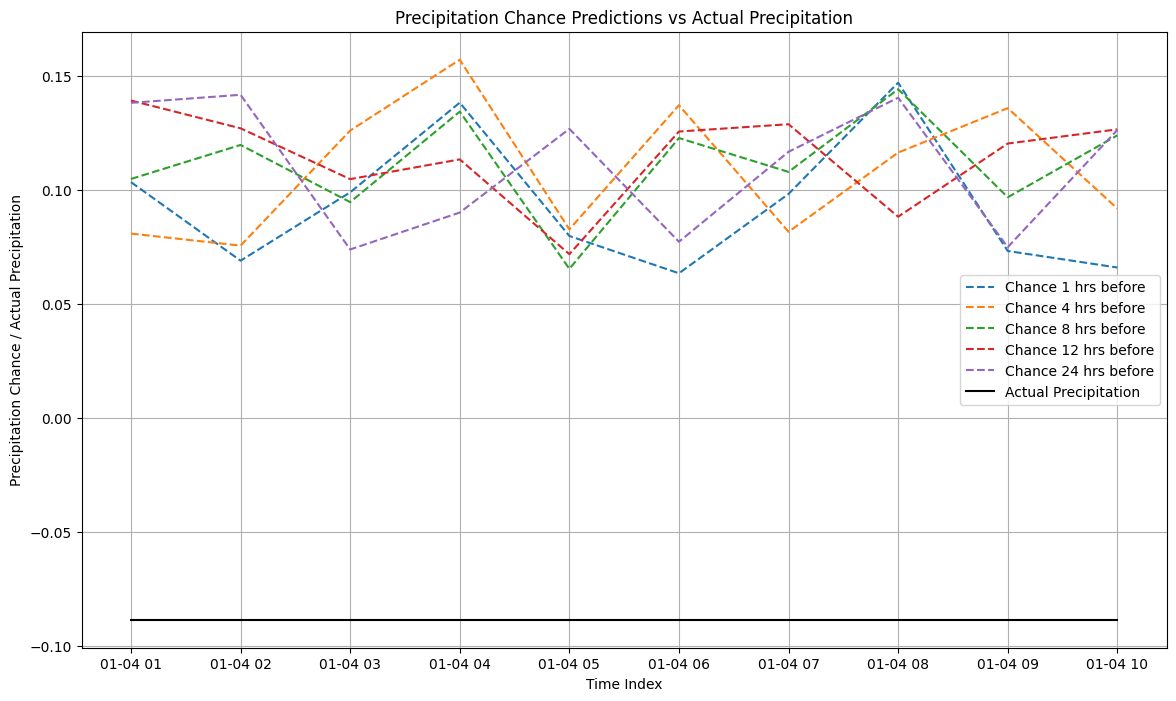

In [9]:
import matplotlib.pyplot as plt

def plot_precipitation_chances(df, target_intervals=[1, 4, 8, 12, 24], actual_column='Ppt', timeframe=(0, 100)):
    """
    Plots precipitation chance predictions at different intervals against the actual precipitation values.
    
    Parameters:
        df (pd.DataFrame): DataFrame containing the precipitation chance columns and actual precipitation values.
        target_intervals (list): List of intervals (in hours) for which the precipitation chance is calculated.
        actual_column (str): Name of the actual precipitation column in the DataFrame.
        timeframe (tuple): Tuple (start, end) indicating the index range to plot for better visualization.
    """
    start, end = timeframe
    plt.figure(figsize=(14, 8))
    
    # Plot each interval's precipitation chance
    for interval in target_intervals:
        plt.plot(df.index[start:end], df[f'precip_chance_{interval}_hrs'][start:end], label=f'Chance {interval} hrs before', linestyle='--')
    
    # Plot actual precipitation values
    plt.plot(df.index[start:end], df[actual_column][start:end], label='Actual Precipitation', color='black', linewidth=1.5)
    
    # Customize the plot
    plt.xlabel('Time Index')
    plt.ylabel('Precipitation Chance / Actual Precipitation')
    plt.title('Precipitation Chance Predictions vs Actual Precipitation')
    plt.legend()
    plt.grid(True)
    plt.show()

plot_precipitation_chances(df, timeframe=(0, 10))


In [3]:
time_intervals = [1, 4, 8, 12, 24]  # in hours
for interval in time_intervals:
    for feature in ['Ppt', 'RH', 'Srad']:
        df[f'{feature}_{interval}h'] = df[feature].shift(interval)

# Drop any rows with NaNs created by lagging
df.dropna(inplace=True)

# Define target variable (binary, e.g., 1 if rain occurred, 0 if not)
df['rain_next'] = (df['Ppt'].shift(-1) > 0).astype(int)
df.head()

,Ppt,Ppt.1,Tair,RH,Srad,Wx,Wy,Day sin,Day cos,Year sin,...,Ppt_8h,RH_8h,Srad_8h,Ppt_12h,RH_12h,Srad_12h,Ppt_24h,RH_24h,Srad_24h,rain_next
2015-01-02 00:00:00,-0.088477,-0.088526,-1.971223,1.464835,-0.683304,0.561938,0.585589,-1.275833e-11,1.414165,-0.024262,...,-0.088477,1.412407,-0.551854,0.689112,1.419397,-0.405783,-0.088477,0.898607,-0.683236,0
2015-01-02 01:00:00,-0.088477,-0.088526,-1.958920,1.464835,-0.683304,0.697494,0.030279,3.660254e-01,1.365978,-0.023241,...,-0.088477,1.443864,-0.622385,0.433326,1.419397,-0.418170,-0.088477,0.849674,-0.682627,0
2015-01-02 02:00:00,-0.088477,-0.088526,-2.008470,1.475321,-0.683304,0.850233,0.316628,7.071068e-01,1.224700,-0.022221,...,-0.088477,1.450854,-0.673726,0.167309,1.408911,-0.349534,-0.088477,0.811226,-0.682627,0
2015-01-02 03:00:00,-0.088477,-0.088526,-2.012082,1.475321,-0.683067,0.565142,0.495874,1.000000e+00,0.999959,-0.021201,...,-0.088477,1.447359,-0.683304,-0.088477,1.387940,-0.445956,-0.088477,0.821712,-0.682729,0
2015-01-02 04:00:00,-0.088477,-0.088526,-1.977318,1.478816,-0.683270,0.454679,0.741537,1.224745e+00,0.707070,-0.020181,...,-0.088477,1.457845,-0.683304,-0.088477,1.412407,-0.551854,0.167309,1.097835,-0.683270,1


In [4]:
X = df.drop(columns=['Ppt', 'rain_next'])  # Drop columns not used as features
y = df['rain_next']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [5]:
mlr_model = tf.keras.Sequential([
    tf.keras.layers.Dense(1, input_shape=(X_train.shape[1],))
])

# Compile the model
mlr_model.compile(optimizer='adam', loss='mse')

# Train the model
mlr_model.fit(X_train, y_train, epochs=100, batch_size=32, validation_split=0.2, verbose=1)

/Users/michaeltao/Desktop/CS370/tx-soil-moisture/venv_3.11/lib/python3.11/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
1169/1169 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.6587 - val_loss: 0.1349
Epoch 2/100
1169/1169 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.1070 - val_loss: 0.0443
Epoch 3/100
1169/1169 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.0403 - val_loss: 0.0297
Epoch 4/100
1169/1169 ━━━━━━━━━━━━━━━━━━━━ 1s 901us/step - loss: 0.0296 - val_loss: 0.0290
Epoch 5/100
1169/1169 ━━━━━━━━━━━━━━━━━━━━ 1s 685us/step - loss: 0.0296 - val_loss: 0.0293
Epoch 6/100
1169/1169 ━━━━━━━━━━━━━━━━━━━━ 1s 763us/step - loss: 0.0289 - val_loss: 0.0294
Epoch 7/100
1169/1169 ━━━━━━━━━━━━━━━━━━━━ 1s 656us/step - loss: 0.0300 - val_loss: 0.0294
Epoch 8/100
1169/1169 ━━━━━━━━━━━━━━━━━━━━ 1s 703us/step - loss: 0.0294 - val_loss: 0.0299
Epoch 9/100
1169/1169 ━━━━━━━━━━━━━━━━━━━━ 1s 732us/step - loss: 0.0294 - val_loss: 0.0295
Epoch 10/100
1169/1169 ━━━━━━━━━━━━━━━━━━━━ 1s 755us/step - loss: 0.0297 - val_loss: 0.0289
Epoch 11/100
1169/1169 ━━━━━━━━━━━━━━━━━━━━ 1s 837us/step - loss: 0.0300 - val_loss: 0.0288
Epo

In [ ]:
# Get predictions for the test set
mlr_predictions = mlr_model.predict(X_test).flatten()

# # Plot predictions against actual values
# plot_data = plot_single_pred(model=mlr_model, 
#                              name="Multiple Linear Regression (TensorFlow)", 
#                              dataset=X_test, 
#                              data_steps=1,  # Set to 1 as MLR predicts one step at a time
#                              y=y_test)
